# <b>Apprentissage automatique</b>
## Régression linéaire et K-NN (K plus proches voisons) en régression
#### (Voir plus de détails dans Introduction to Statistical Learning, 2nd Edition par James, Witten, Hastie, Tibshirani)


###  Modèle de régression

Soit le modèle de régression

$Y=f(X)+\epsilon$, $X=(X^1,X^2,...,X^p)$, $X\in \mathcal{X}$, $Y\in \mathcal{Y}$


Nous avons vu que le choix de $f$ qui minimise $E[(Y-g(x))^2|X=x]$ pour tout $X$ est
$f(x)=E(Y|X=x)$

$\epsilon = Y-f(x)$ est l'erreur irréductible, et pour toute estimation $\hat f(x)$ de $f(x)$,

$E[(Y-\hat f(X))^2|X=x]=[f(x)-\hat f(x)]^2+Var(\epsilon)$

Le premier terme du côté droit est l'erreur réductible, c'est-à-dire qu'elle diminue lorsque l'estimation se rapproche de la vraie fonction $f$, tandis que le deuxième terme est irréductible, lié à la dispersion des données.


Soit un ensemble d'entraînement $S=\{x_1,...,x_n\}$,  donné pour l'estimation de $f$ avec une méthodé donnée.

* $\mathcal{X}$  est appelé domaine des instances
* $x_i\in \mathcal{X}$  est appelé entrée ou instance d'apprentissage
* $\mathcal{Y}$ est l'ensemble des étiquettes possibles.
* $y_i\in \mathcal{Y}$ est appelé sortie, cible, ou label d'apprentisage


### Régressions linéaire et k-NN

* La régression linéaire suppose une forme paramètrique linéaire de $f$. Les méthodes non paramétriques ne font pas de telles hypothèses, ce qui offre une manière plus flexible d'effectuer une régression:

$f(X)=\beta^\top \mathbf{X}$

$\beta=(\beta_0,...,\beta_p)^\top$, $\mathbf{X}=(1, X^1,...,X^p)^\top$


Dans de nombreux cas, il y a très peu de points à $X_i=𝑥$ , on peut donc calculer $𝑓(𝑥)$ en utilisant les points dans le voisinage de $𝑥$. On l'appelle cela la moyenne des voisins les plus proches ou la moyenne locale.

* La régression des (k-NN) est une des méthodes non-paramètriques les plus usuelles. Le k-NN estime $f(x)$ en prenant la moyenne des $k$ observations d'entraînement les plus proches.

$\hat f(x) = \frac {1}{k} \sum_{x_i \in \mathcal{N}_x} y_i.$

avec $x_1,...,x_n$ l'ensemble d'apprentissage, $\mathcal{N}_x$ est l'ensemble des $k$ instances d'entraînement les plus proches de $x$ d'après une distance pré-définie.

Pour de plus petites valeurs de $k$, l'ajustement est généralement une approximation grossière en forme de fonction escalier, qui devient plus lisse quand $k$ augmente. Cependant, des valeurs plus élevées de $k$ peuvent effacer des détails importants de l'ajustement. Le $k$ optimal peut être trouvé en appliquant le compromis biais-variance.

* Les modèles paramétriques surpassent les modèles non paramétriques si le modèle paramétrique sélectionné est proche de la véritable forme de $f$. Pour un grand nombre de dimensions (malédiction de la dimensionnalité) ou pour un échantillonnage clairsemé, les modèles paramétriques surpasseront les méthodes k-NN également. Étant donné que les modèles linéaires sont meilleurs pour la facilité d'interprétation et pas que, ils  pourraientt être préférés au k-NN, même si cela signifie que l'ajustement n'est pas aussi bon. Cette décision dépendrait de la situation et du résultat souhaité.


#### Compromis entre biais et variance

Pour évaluer l'exactitude d'un modèle:

* calculer l'erreur de prédiction moyenne au carré sur l'ensemble d'entraînement
* Peut être biaisé vers le surajustement, donc utiliser des données supplémentaires, différentes de l'ensemble d'entraînement.

Compromis biais-variance :

$E(Y-\hat f(x))^2=Var(\hat f(x))+[Bias(\hat f(x))]^2+Var(\epsilon)$

où la variance de $\hat f$ indique la variabilité que $\hat f$ prend lorsque l'expérience est répétée plusieurs fois avec un ensemble de données différent,

et $Bias(\hat f(x))=E[\hat f(x)]-f(x)$.

À mesure que la flexibilité de $\hat f$ augmente, sa variance augmente également, et le biais diminue. La flexibilité doit être choisie pour équilibrer le compromis biais-variance.

#### Fléau de la dimension p

La malédiction de la dimensionnalité : les voisins les plus proches ont tendance à être éloignés dans les dimensions élevées, mais il faut moyenner de nombreux voisins les plus proches pour obtenir une estimation précise. Dans les dimensions élevées, les voisins les plus proches peuvent ne pas être locaux, ce qui peut entraîner une perte de l'aspect local de l'estimation.

Les modèles linéaires ne sont souvent pas corrects, mais ils fournissent un résultat interprétable. On peut ajouter des termes quadratiques pour obtenir un meilleur ajustement. Il faut faire attention au surajustement (comment savoir quand c'est juste?)

Différentes méthodes présentent un compromis entre interprétabilité et flexibilité. De l'interprétabilité élevée/flexibilité faible à l'interprétabilité faible/flexibilité élevée : sélection de sous-ensemble, Lasso ; moindres carrés ; modèles additifs généralisés, arbres ; bagging, boosting ; machines à vecteurs de support.

### Régression linéaire

In [ ]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from matplotlib import cm

In [ ]:
advertising = pd.read_csv('Advertising.csv')
advertising = advertising.drop(columns = 'Unnamed: 0', axis =1)
advertising.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


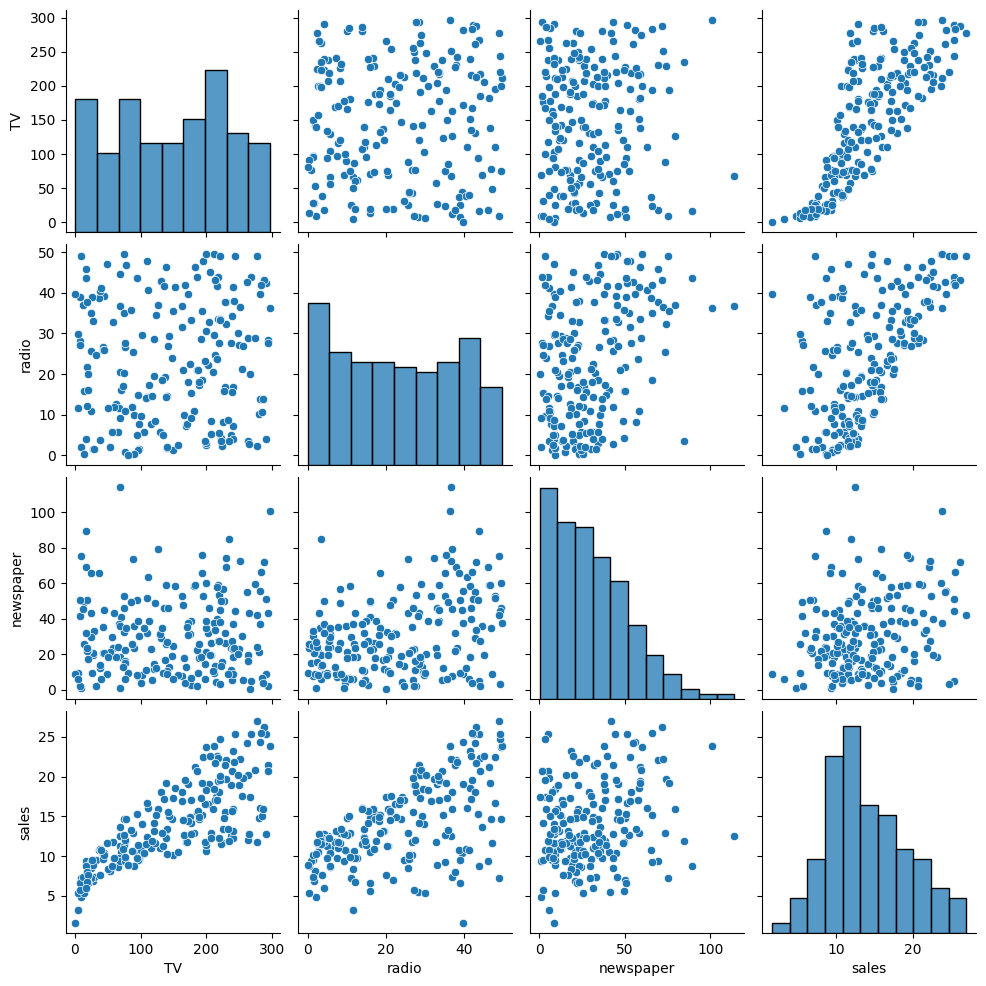

In [ ]:
sns.pairplot(advertising)

Relation linéaire entre TV et Sales (réponse, étiquette)

/tmp/ipython-input-277085347.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(0,25,['Linear Fit: sales = '+ str(round(float(slope),3))+ ' * TV + '+ str(int(inter))],color='darkred');


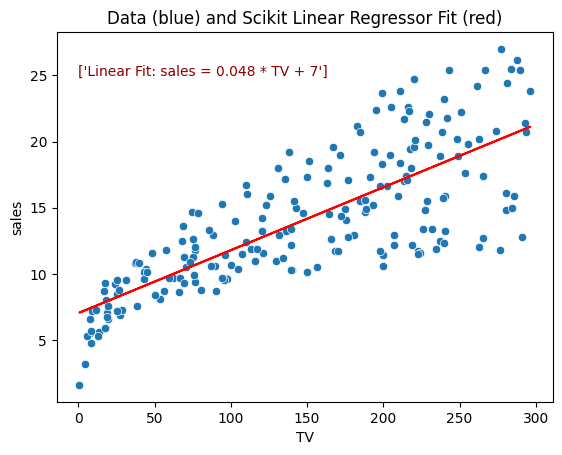

In [ ]:
sns.scatterplot(y = advertising.sales,x = advertising.TV)

from sklearn.linear_model import LinearRegression
X = advertising[['TV']]
y = advertising[['sales']]
regress = LinearRegression()
regress.fit(X,y)
y_pred = regress.predict(X)
plt.plot(X,y_pred,color = 'red')
plt.title('Data (blue) and Scikit Linear Regressor Fit (red)');
inter = regress.intercept_
slope = regress.coef_
graphtext = '{float(slope)}*TV+ {int(inter)}'
plt.text(0,25,['Linear Fit: sales = '+ str(round(float(slope),3))+ ' * TV + '+ str(int(inter))],color='darkred');


#### Qualité de l'estimation, de la prédiction

Pour calculer l'erreur quadratique moyenne (EQM) pour différentes combinaisons de $\beta_0$ et $\beta_1$, il faut d'abord définir les valeurs prédites $\hat{y}_i$ pour chaque observation $i$ en fonction du modèle linéaire : $\hat y_i=\beta_0+\beta_1 x_i$

où $x_i$ est la variable prédictrice pour l'observation $i$.

L'EQM est calculée comme la moyenne des différences au carré entre les valeurs observées $y_i$ et les valeurs prédites $\hat{y}_i$

Voici comment il faut calculer l'EQM pour différentes combinaisons de $\beta_0$ et $\beta_1$ :

   * Parcourez différentes valeurs de $\beta_0$ et $\beta_1$.
   * Pour chaque combinaison de $\beta_0$ et $\beta_1$, calculez les valeurs prédites $\hat{y}_i$.
   * Calculez les différences au carré entre les valeurs observées $y_i$ et les valeurs prédites $\hat{y}_i$.
   * Faites la moyenne des différences au carré pour obtenir l'EQM.

Ensuite il faut comparer les valeurs d'EQM pour différentes combinaisons de $\beta_0$ et $\beta_1$ pour trouver la combinaison qui minimise l'EQM, ce qui indique le meilleur modèle linéaire d'ajustement.

#### Erreur d'entrainement et de généralisation

* L'erreur d'entraînement (ou erreur de train) est la fonction de perte calculée sur l'ensemble d'entraînment. Les exemples d'entraînement ont été générés par une distribution inconnue

Une façon plus adéquate de calculer la qualité de prédiction du modèle est de calculer ses erreurs sur des exemples non vus en entraînement mais générés par la même distribution.

* L'erreur de généralisation est la fonction de perte calculée sur un ensemble dit de test, non utilisés en entraînement mais générés par la même distribution  que celle de l'entrainement

In [ ]:
from sklearn.metrics import mean_squared_error

b0,b1 = np.mgrid[5:9:0.1,0.02:0.07:0.001]
pos = np.dstack((b0,b1))
msevals = np.zeros(np.shape(pos[:,:,1]))
for i in b0[:,0]:
    idxi = np.where(b0[:,0] == i)
    for j in b1[0,:]:
        idxj = np.where(b1[0,:] == j)
        ypred = j* X.values + i
        msevals[int(idxi[0]),int(idxj[0])] = mean_squared_error(y,ypred)


plt.figure(figsize=(4,4))
plt.contour(b0,b1,msevals,levels = np.linspace(10,15,7));
plt.scatter(inter,slope,color='r')
plt.xlabel('beta0')
plt.ylabel('beta1');

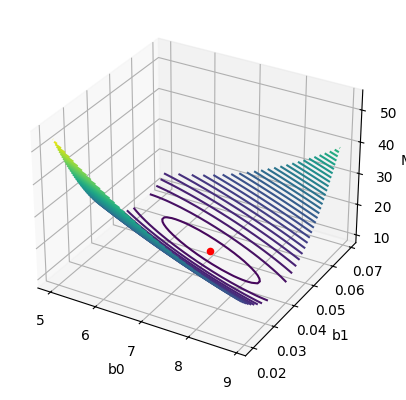

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(b0,b1,msevals,50)
ax.set_xlabel('b0')
ax.set_ylabel('b1')
ax.set_zlabel('MSE')
ypred = slope* X.values + inter
bestmse = mean_squared_error(y,ypred)
ax.scatter(inter,slope,bestmse,color='r');

Régression linéaire multiples

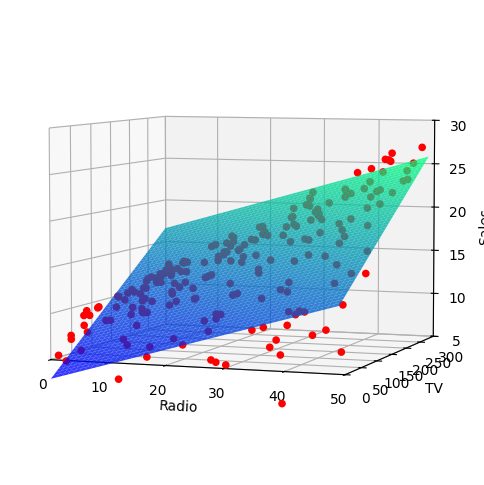

In [ ]:



X = advertising[['TV', 'radio']]
y = advertising['sales']   # 1D target

# Regression lineaire
regress = LinearRegression()
regress.fit(X, y)

# Parametres estimes
intercept = regress.intercept_
coef_TV, coef_radio = regress.coef_

# Grille pour estimatin
radio_grid = np.arange(0, 50, 1)
TV_grid = np.arange(0, 300, 1)
radio_grid, TV_grid = np.meshgrid(radio_grid, TV_grid)

Zmodel = intercept + coef_radio * radio_grid + coef_TV * TV_grid

# Plot
fig = plt.figure(figsize=(6, 20))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('Radio')
ax.set_ylabel('TV')
ax.set_zlabel('Sales')

surf = ax.plot_surface(
    radio_grid, TV_grid, Zmodel,
    cmap=cm.winter, alpha=0.8
)

ax.scatter(
    X['radio'], X['TV'], y,
    color='red', alpha=1
)

#
ax.azim = -70
ax.elev = 5
ax.dist = 10

ax.set_xlim([0, 50])
ax.set_ylim([0, 300])
ax.set_zlim([5, 30])

plt.show()


Matrice de corrélation

In [ ]:
reduced_ad=advertising[{'TV','radio','newspaper','sales'}]
reduced_ad.corr()

,TV,sales,radio,newspaper
TV,1.000000,0.782224,0.054809,0.056648
sales,0.782224,1.000000,0.576223,0.228299
radio,0.054809,0.576223,1.000000,0.354104
newspaper,0.056648,0.228299,0.354104,1.000000


In [ ]:
print('Intercept = ' + str(inter))
print('Slopes (TV, radio, newspaper) = ' + str(slopes))

Intercept = [2.93888937]
Slopes (TV, radio, newspaper) = [[ 0.04576465  0.18853002 -0.00103749]]


In [ ]:
# The y variable in the kernel state is a Series from ONzNNzWsbOPc: y = advertising['sales']
# The regress object was also fitted in ONzNNzWsbOPc using X = advertising[['TV', 'radio']]
# We need to compute y_pred based on this model to ensure correct shapes.
X_for_predict = advertising[['TV', 'radio']] # Use the features used for fitting the current `regress` model
y_pred = regress.predict(X_for_predict) # This will produce a 1D array of shape (200,)

MSE = np.sum(np.square(y-y_pred))
RMSE = np.sqrt(MSE/(len(y)-2))
TSE = np.sum((y - np.mean(y))**2)
p = X_for_predict.shape[1] # Number of predictors (TV, radio) = 2
Rsq=1-MSE/TSE
F = (TSE-MSE)/p /(MSE/(len(y)-p-1))
print('RSE = ' + str(float(RMSE)))
print('R^2 = ' + str(float(Rsq)))
print('F-statistic = ' + str(float(F)))

RSE = 1.6771096771017615
R^2 = 0.8971942610828957
F-statistic = 859.6177183058213


Pour les prédicteurs qualitatifs avec seulement deux niveaux, on peut créer une variable fictive (dummy variable) qui prend la valeur 0 ou 1, et l utiliser dans l équation de régression. On peut également utiliser -1 ou 1. Il suffit d'ajuster le modèle en conséquence pour tenir compte du choix.

Par exemple, supposons que nous ayons une variable qualitative binaire nommée $X$, où les niveaux sont "A" et "B". Nous pouvons créer une variable fictive $D$ de la manière suivante :

$$
D = \begin{cases}
1 & \text{si } X = \text{"B"} \\
0 & \text{si } X = \text{"A"}
\end{cases}
$$

Nous utilisons ensuite cette variable fictive $D$ dans la régression linéaire comme suit :

$$
Y = \beta_0 + \beta_1 D + \epsilon
$$

Ici, $\beta_0$ est ordonnée à l'origine, $\beta_1$ est le coefficient de la variable fictive $D$, et $\epsilon$ est le terme d erreur.

Si vous choisissez dutiliser -1 ou 1 pour la variable fictive, l'équation devient :

$$
Y = \beta_0 + \beta_1 D + \epsilon
$$

Dans ce cas, $\beta_1$ représentera un effet moyen sur la réponse lorsque la variable qualitative est à son niveau "B" par rapport à son niveau "A".

En ajustant le modèle de cette manière, nous pouvons incorporer des prédicteurs qualitatifs dans la régression linéaire, ce qui élargit la portée de l analyse des données.

In [ ]:
# OLS avec statsmodels

import statsmodels.api as sm

est = sm.OLS(y,X)
ests = est.fit()
print(ests.summary())

                                 OLS Regression Results                                
Dep. Variable:                  sales   R-squared (uncentered):                   0.981
Model:                            OLS   Adj. R-squared (uncentered):              0.981
Method:                 Least Squares   F-statistic:                              5206.
Date:                Tue, 13 Jan 2026   Prob (F-statistic):                   6.73e-172
Time:                        22:18:24   Log-Likelihood:                         -426.71
No. Observations:                 200   AIC:                                      857.4
Df Residuals:                     198   BIC:                                      864.0
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### k-NN en régression

In [ ]:
train = pd.read_csv("simpledata_train.csv")
train.shape

(50, 2)

<Axes: xlabel='x', ylabel='y'>

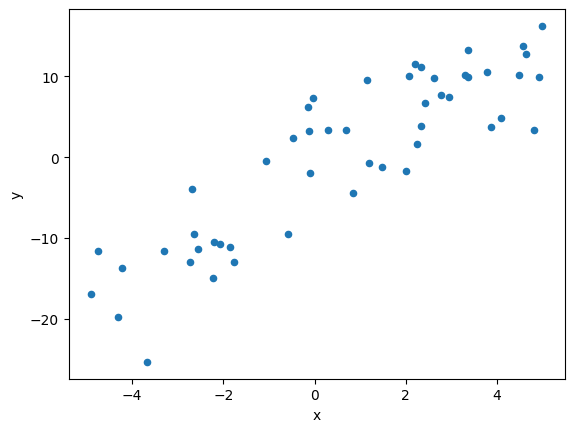

In [ ]:
train.plot.scatter("x", "y")

In [ ]:
from sklearn import neighbors
# #############################################################################
# Modek Knn de regression  avec k=2
k = 2
X = train["x"].values[:,np.newaxis] # Matrice colonne plutôt que vecteur ligne
y = train["y"]

knn = neighbors.KNeighborsRegressor(k)
knn.fit(X, y)

KNeighborsRegressor(n_neighbors=2)

Visualiser la règle de prédiction

Text(0.5, 1.0, 'KNeighborsRegressor k = 2')

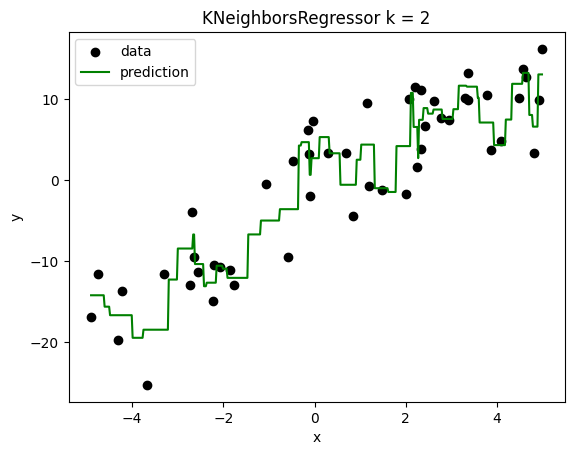

In [ ]:
xsupport = pd.DataFrame(np.linspace(min(train.x),max(train.x),500))
y_ = knn.predict(xsupport)

plt.scatter(train["x"], train["y"], c='k', label='data')
plt.plot(xsupport.values, y_, c='g', label='prediction')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("KNeighborsRegressor k = " + str(k))

Erreur d'entrainement

In [ ]:
from sklearn.metrics import mean_squared_error
yhat_train = knn.predict(X)
mean_squared_error(y, yhat_train)

12.366034124597014

Erreur de généralisation

In [ ]:
# Lire les données de test
test = pd.read_csv("simpledata_test.csv")
X_test = test["x"].values[:,np.newaxis]
y_test = test["y"]

# Faire des prédictions en utilisant le modèle entrainé sur les données de train
yhat_test = knn.predict(X_test)

# Calcul de l'erreur de généralisation
mean_squared_error(y_test, yhat_test)

35.03502108936177

In [ ]:
from sklearn.metrics import explained_variance_score
print("Erreur de train normalisée (1-explained var)",1-explained_variance_score(y, yhat_train))
print("Erreur de généralisation normalisée (1-explained var)",1-explained_variance_score(y_test, yhat_test))

Erreur de train normalisée (1-explained var) 0.11811363552116605
Erreur de généralisation normalisée (1-explained var) 0.39505622849040356


#### Choix de k
Pour des valeurs de $k$ allant de 1 à 25 on entraîne un regresseur k-plus proche voisin sur l'ensemble d'entraînement, puis évalue la qualité des prédictions du regresseur sur l'ensemble d'entraînement et sur l'ensemble de test. Les erreurs sont stockées dans une liste pour être restituées sous forme d'un graphique.

In [ ]:
gen_errors = [] # erreurs de généralisation
emp_errors = [] # erreurs empiriques
k_vals = list(range(1,25))

for k in k_vals:
    # Entrainement
    knn = neighbors.KNeighborsRegressor(k)
    knn.fit(X, y)
    # Prediction
    yhat_train = knn.predict(X)
    emp_errors.append(1-explained_variance_score(y, yhat_train))
    yhat_test = knn.predict(X_test)
    gen_errors.append(1-explained_variance_score(y_test, yhat_test))

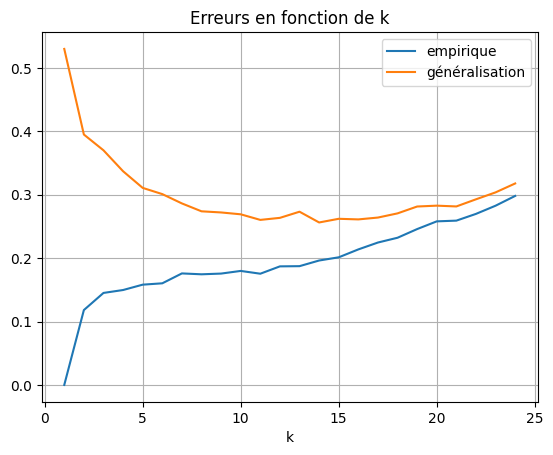

In [ ]:
k_errors = pd.DataFrame({"k":k_vals,"empirique":emp_errors,"généralisation":gen_errors})
ax=k_errors.plot(kind="line",x="k",y="empirique")
k_errors.plot(kind="line",x="k",y="généralisation", ax=ax)
plt.title("Erreurs en fonction de k")
plt.grid()
plt.legend()

On constate que quand $k=0$ la performance du regresseur est optimale sur l'ensemble d'entraînement (pas d'erreurs) mais que l'erreur est à son plus haut niveau sur l'ensemble de test: Il y a sur-apprentissage. Quand $k$ augmente la performance du regresseur sur l'ensemble d'entraînement se dégrade constamment. Sur l'ensemble de test la performance s'améliore constammment pour finalement se détériorer après $k=15$.

#### Répétition de la procédure

On tire de façon répétée un ensemble d'entraînement: sur lequel on "apprend" un regresseur de k-plus proches voisins
pour lequel on évalue la qualité des prédictions sur l'ensemble d'entraînement et sur un ensemble de test. On calcule la moyenne et l'écart type des valeurs des erreurs sur l'ensemble des répétitions.

In [ ]:
def polynom_sample(x, coefs, sigma=5):
    """Une fonction pour associer un vecteur y e un vecteur x avec
    une relation polynomiale de coefficient coefs et un bruit gaussien
    de variance sigma"""
    d = len(coefs) # le degre du polynome
    y = sigma*np.random.randn(*x.shape) # intialise avec bruit gaussien
    for i in range(d): # accumule le calcul du polynome
        y = y + coefs[i]*( x**i)
    return y

def data_sample(N):
    """Une fonction qui genere un ensemble de donnees de taille N tirees d'un polynome particulier"""
    a = -5 # borne inf
    b = 5 # borne sup
    coefs = [0, 4.63235734e+00,  -6.39114341e+00,
             -6.32024032e-01,   1.89403935e+00,   1.17905282e-01,
             -2.11509996e-01,  -7.77580853e-03,   9.75144372e-03,
             1.59857817e-04,  -1.57464310e-04]
    x = (b-a)*np.random.random_sample(N) + a # N points tires uniformement de l'intervalle [a,b]
    y = polynom_sample(x, coefs)
    df = pd.DataFrame({"x":x,"y":y})
    return df



k = 10
repeats = 200
gen_errors = [] # erreurs de généralisation
emp_errors = [] # erreurs empiriques

for r in range(repeats):
    # Pretraitement
    train2 = data_sample(50)
    X = train2["x"].values[:,np.newaxis]
    y = train2["y"]
    # Entrainement
    knn = neighbors.KNeighborsRegressor(k)
    knn.fit(X, y)
    # Prediction
    yhat_train = knn.predict(X)
    emp_errors.append(1-explained_variance_score(y, yhat_train))#mean_squared_error(y, yhat_train))
    yhat_test = knn.predict(X_test)
    gen_errors.append(1-explained_variance_score(y_test, yhat_test))#mean_squared_error(y_test, yhat_test))

In [ ]:
train_sample_errors = pd.DataFrame({"empirical":emp_errors,"generalization":gen_errors})
train_sample_errors.describe()



,empirical,generalization
count,200.000000,200.000000
mean,0.219545,0.313756
std,0.050083,0.038451
min,0.099926,0.232833
25%,0.183896,0.286906
50%,0.214998,0.311691
75%,0.251690,0.336025
max,0.431358,0.503179


<Axes: >

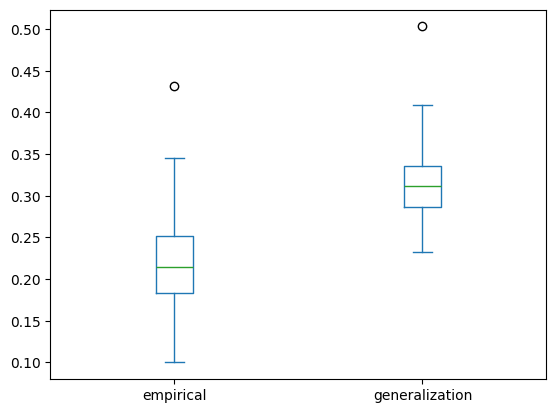

In [ ]:
train_sample_errors.plot.box()

On constate que la valeur des erreurs varie avec le choix de l'ensemble d'entraînement avec un écart type non négligeable.

#### Pour avoir une meilleure estimation de l'erreur de généralisation on génére en plus un ensemble de test.

Pour des valeurs de allant de 25 à 200 par incrément de 25:

On tire de façon répétée un ensemble d'entraînement: sur lequel on "apprend" un regresseur de k-plus proches voisins pour lequel on évalue la qualité des prédictions sur l'ensemble d'entraînement et sur un ensemble de test.
On calcule la moyenne et l'écart type des valeurs des erreurs sur l'ensemble des répétitions.

In [ ]:
test2 = data_sample(100) #pd.read_csv("./simpledata_test.csv")
X_test = test2["x"].values[:,np.newaxis]
y_test = test2["y"]

k = 10

repeats = 200
m_gen_errors = [] # erreurs generalisation
m_emp_errors = [] # erreurs  training

for m in range(25, 200, 25):
    gen_errors = [] # erreurs generalisation
    emp_errors = [] # erreurs  training
    for r in range(repeats):
        # Preprocess
        train2 = data_sample(m)
        X = train2["x"].values[:,np.newaxis] #
        y = train2["y"]
        # Train
        knn = neighbors.KNeighborsRegressor(k)
        knn.fit(X, y)
        # Prediction
        yhat_train = knn.predict(X)
        emp_errors.append(1-explained_variance_score(y, yhat_train))#mean_squared_error(y, yhat_train))
        yhat_test = knn.predict(X_test)
        gen_errors.append(1-explained_variance_score(y_test, yhat_test))#mean_squared_error(y_test, yhat_test))
    m_gen_errors.append([m, np.mean(gen_errors), np.std(gen_errors)])
    m_emp_errors.append([m, np.mean(emp_errors), np.std(emp_errors)])

In [ ]:
taille_train_emp_errors=pd.DataFrame(m_emp_errors, columns=["m","mean emp","std emp"])
taille_train_gen_errors=pd.DataFrame(m_gen_errors, columns=["m","mean gen","std gen"])
taille_train_gen_errors.head()

,m,mean gen,std gen
0,25,0.280005,0.047051
1,50,0.218462,0.019284
2,75,0.203743,0.017247
3,100,0.198261,0.014438
4,125,0.193870,0.015136


<Axes: xlabel='m'>

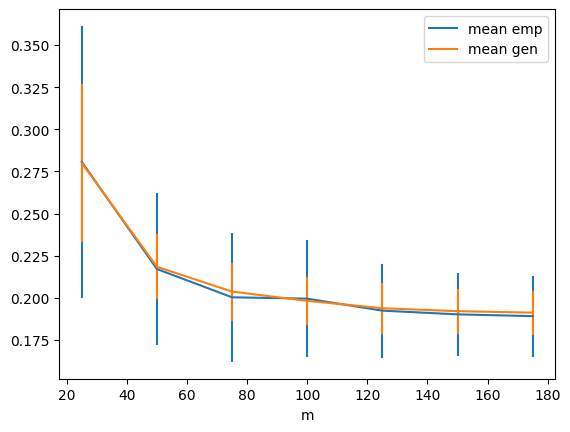

In [ ]:
ax = taille_train_emp_errors.plot(kind="line",x="m",y="mean emp", yerr="std emp")
taille_train_gen_errors.plot(kind="line",x="m",y="mean gen", yerr="std gen",ax=ax)

## TD

* Chargez les données San_People_stats1.csv. Décrivez les données.  Quelle est la distribution des âges? Des sexes?
* Visualisez les données (scatter) en utilisant les 2 premières colonnes. Colorisez en fonction de l'âge (vous pouvez choisir votre palette de couleurs https://matplotlib.org/stable/users/explain/colors/colormaps.html). Que constatez vous?
* On veut prédire l'âge des individus. En utilisant train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) découper les données en ensemble d'entraînement (2/3 des exemples) et ensemble de test (1/3 des exemples).
* En utilisant comme domaine des instances l'espace décrit par les variables height et weight entraînez un modèle linéaire et un modéle de k-plus proches voisins. Expliquez comment vous choisissez la meilleure valeur de k. Comparez les 2 modèles
* Ajoutez au domaine de instances la variable male et entraînez un modèle de k-plus proches voisins. Comparez.

1) Chargeons les données San_People_stats1.csv.

In [ ]:
dataSan = pd.read_csv("San_People_stats1.csv", sep=';')
dataSan.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


2) Décrivons les données. Quelle est la distribution des âges? Des sexes?

3) Visualisez les données (scatter) en utilisant les 2 premières colonnes. Colorisez en fonction de l'âge (vous pouvez choisir votre palette de couleurs

4) On veut prédire l'âge des individus. En utilisant train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) découper les données en ensemble d'entraînement (2/3 des exemples) et ensemble de test (1/3 des exemples).

5) Utilisez la même démarche et ajouter la variable binaire 'male' comme variable explicative